# LendingClub Credit Scorecard v2 — Individual Applications Only

Revamps the `fico_percentile` scorecard from `scorecard.ipynb` with the one
feature-engineering addition that actually earned its place, **and** narrows the
population to individual applications only — dropping Joint App loans.

**Why filter out Joint App loans:** a joint application combines two people's
finances. `annual_inc`, `dti`, and similar fields mean something structurally
different for a joint applicant (combined household figures) than for an
individual one, and LendingClub even provides separate `annual_inc_joint`/
`dti_joint` fields for that population. Modeling both populations together with
one feature set risks blurring what those fields actually represent. This version
isolates the individual-applicant segment (~94.7% of volume) so the existing
feature set describes a single, coherent population. Joint applications would be
a reasonable candidate for their own separate scorecard using the joint-specific
fields, but that's out of scope here.

**Feature set:** same as `scorecard.ipynb` (v1) plus `loan_to_income` — the one
addition from the v2 feature-expansion round that actually improved out-of-time
performance. Everything else tested in that round (`credit_history_years`,
delinquency-recency fields, `acc_now_delinq`, `tax_liens`, `addr_state`, `bc_util`)
was dropped for failing to clear the IV bar or (for `bc_util`) clearing it while
adding no real lift — see `scorecard_adv.ipynb`'s git history / the README for
that analysis.

Same out-of-time design and leakage-avoidance rules as `scorecard.ipynb`: train on
loans issued 2007–2015, test on 2016; no `grade`/`sub_grade`/`int_rate`/
`installment`; FICO handled as a rolling percentile, not a raw score.

In [1]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

path = kagglehub.dataset_download("wordsforthewise/lending-club")
print("Dataset path:", path)

Dataset path: /Users/andreastio/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3


## 1. Load & prepare data

In [2]:
usecols = [
    "loan_amnt", "term", "emp_length", "home_ownership", "annual_inc",
    "verification_status", "issue_d", "loan_status", "purpose", "dti",
    "delinq_2yrs", "inq_last_6mths", "fico_range_low", "fico_range_high",
    "open_acc", "pub_rec", "revol_bal", "revol_util", "total_acc",
    "mort_acc", "pub_rec_bankruptcies", "application_type",
]

csv_path = f"{path}/accepted_2007_to_2018Q4.csv.gz"
df = pd.read_csv(csv_path, usecols=usecols, low_memory=False)
print(df.shape)

(2260701, 22)


In [3]:
def parse_emp_length(x):
    if pd.isna(x):
        return np.nan
    if "<" in x:
        return 0.0
    digits = "".join(ch for ch in x if ch.isdigit())
    return float(digits) if digits else np.nan

df["term_months"] = df["term"].str.extract(r"(\d+)").astype(float)
df["revol_util"] = df["revol_util"].astype(str).str.rstrip("%").replace("nan", np.nan).astype(float)
df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y")
df["emp_length_years"] = df["emp_length"].apply(parse_emp_length)
df["fico_mid"] = (df["fico_range_low"] + df["fico_range_high"]) / 2
df["loan_to_income"] = df["loan_amnt"] / df["annual_inc"].replace(0, np.nan)

print("application_type breakdown (before filtering):")
print(df["application_type"].value_counts())

df = df[df["application_type"] == "Individual"].copy()

bad_statuses = ["Charged Off", "Default"]
good_statuses = ["Fully Paid"]
resolved = df[df["loan_status"].isin(bad_statuses + good_statuses)].copy()
resolved["is_default"] = resolved["loan_status"].isin(bad_statuses).astype(int)

train = resolved[resolved["issue_d"] < "2016-01-01"].copy()
test = resolved[(resolved["issue_d"] >= "2016-01-01") & (resolved["issue_d"] < "2017-01-01")].copy()

train_default_rate = train["is_default"].mean()
test_default_rate = test["is_default"].mean()
print(f"\nIndividual-only Train (issued < 2016): {len(train):,} loans, default rate {train_default_rate:.2%}")
print(f"Individual-only Test  (issued 2016)  : {len(test):,} loans, default rate {test_default_rate:.2%}")
print(train[["loan_to_income"]].describe())

application_type breakdown (before filtering):
application_type
Individual    2139958
Joint App      120710
Name: count, dtype: int64



Individual-only Train (issued < 2016): 826,205 loans, default rate 18.42%
Individual-only Test  (issued 2016)  : 287,819 loans, default rate 23.26%
       loan_to_income
count   826205.000000
mean         0.217524
std          0.111125
min          0.000309
25%          0.130435
50%          0.202703
75%          0.295833
max          0.830000


## 2. FICO as a rolling-percentile feature

Same construction as `scorecard.ipynb` — percentile rank against a trailing 6-month window of prior originations.

In [4]:
K_MONTHS = 6

df["issue_month"] = df["issue_d"].dt.to_period("M")

month_ficos = (
    df.dropna(subset=["fico_mid"])
    .groupby("issue_month")["fico_mid"]
    .apply(lambda s: np.sort(s.values))
    .sort_index()
)
all_months = month_ficos.index.tolist()

reference_by_month = {}
for i, m in enumerate(all_months):
    ref_months = all_months[max(0, i - K_MONTHS):i]
    if ref_months:
        reference_by_month[m] = np.sort(np.concatenate([month_ficos[mm] for mm in ref_months]))
    else:
        reference_by_month[m] = month_ficos[m]


def _percentile_within_group(group):
    ref = reference_by_month.get(group.name, np.array([]))
    if len(ref) == 0:
        return pd.Series(np.nan, index=group.index)
    idx = np.searchsorted(ref, group["fico_mid"].values, side="left")
    return pd.Series(idx / len(ref), index=group.index)


df["fico_percentile"] = df.groupby("issue_month", group_keys=False).apply(_percentile_within_group)
df.loc[df["fico_mid"].isna(), "fico_percentile"] = np.nan

train["fico_percentile"] = df.loc[train.index, "fico_percentile"]
test["fico_percentile"] = df.loc[test.index, "fico_percentile"]

## 3. WOE binning

Bin edges / category groupings are derived **only from the training set**, then applied unchanged to the test set.

In [5]:
NUMERIC_FEATURES = [
    "loan_amnt", "annual_inc", "dti", "delinq_2yrs", "fico_percentile",
    "inq_last_6mths", "open_acc", "pub_rec", "revol_bal", "revol_util",
    "total_acc", "mort_acc", "pub_rec_bankruptcies", "emp_length_years",
    "loan_to_income",
]
CATEGORICAL_FEATURES = ["home_ownership", "verification_status", "purpose", "term_months"]

MISSING_LABEL = "Missing"
RARE_LABEL = "Other"
EPS = 0.5


def fit_numeric_bins(series, n_bins=10):
    valid = series.dropna()
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.unique(valid.quantile(quantiles).values)
    edges[0] = -np.inf
    edges[-1] = np.inf
    if len(edges) < 3:
        edges = np.array([-np.inf, np.inf])
    return edges


def apply_numeric_bins(series, edges):
    binned = pd.cut(series, bins=edges, include_lowest=True)
    return binned.astype("object").where(series.notna(), MISSING_LABEL)


def fit_categorical_groups(series, min_share=0.01):
    freq = series.value_counts(normalize=True, dropna=False)
    return set(freq[freq >= min_share].index)


def apply_categorical_groups(series, keep):
    return series.where(series.isin(keep), RARE_LABEL).fillna(MISSING_LABEL)


def compute_woe_table(binned_train, target_train):
    tab = pd.DataFrame({"bin": binned_train, "target": target_train})
    grp = tab.groupby("bin", observed=True)["target"].agg(["count", "sum"])
    grp.columns = ["n", "bad"]
    grp["good"] = grp["n"] - grp["bad"]
    total_good, total_bad = grp["good"].sum(), grp["bad"].sum()
    grp["good_rate"] = (grp["good"] + EPS) / (total_good + EPS * len(grp))
    grp["bad_rate"] = (grp["bad"] + EPS) / (total_bad + EPS * len(grp))
    grp["woe"] = np.log(grp["good_rate"] / grp["bad_rate"])
    grp["iv_component"] = (grp["good_rate"] - grp["bad_rate"]) * grp["woe"]
    return grp


bin_edges, cat_groups, woe_tables, iv_summary = {}, {}, {}, {}

for feat in NUMERIC_FEATURES:
    edges = fit_numeric_bins(train[feat])
    bin_edges[feat] = edges
    binned_train = apply_numeric_bins(train[feat], edges)
    woe_tab = compute_woe_table(binned_train, train["is_default"])
    woe_tables[feat] = woe_tab
    iv_summary[feat] = woe_tab["iv_component"].sum()

for feat in CATEGORICAL_FEATURES:
    keep = fit_categorical_groups(train[feat])
    cat_groups[feat] = keep
    binned_train = apply_categorical_groups(train[feat], keep)
    woe_tab = compute_woe_table(binned_train, train["is_default"])
    woe_tables[feat] = woe_tab
    iv_summary[feat] = woe_tab["iv_component"].sum()

iv_series = pd.Series(iv_summary).sort_values(ascending=False)
iv_series

term_months             0.240269
loan_to_income          0.125344
fico_percentile         0.109982
dti                     0.074900
verification_status     0.051346
loan_amnt               0.036872
annual_inc              0.031302
mort_acc                0.027173
revol_util              0.022288
home_ownership          0.020870
purpose                 0.019824
inq_last_6mths          0.018210
open_acc                0.007931
emp_length_years        0.006469
revol_bal               0.003452
delinq_2yrs             0.001347
pub_rec                 0.000985
pub_rec_bankruptcies    0.000690
total_acc               0.000365
dtype: float64

### Information Value reference

| IV range | Predictive power |
|---|---|
| < 0.02 | Not useful |
| 0.02 – 0.1 | Weak |
| 0.1 – 0.3 | Medium |
| 0.3 – 0.5 | Strong |
| > 0.5 | Suspiciously strong (check for leakage) |

New features are marked in the printed IV table above by name — worth checking
where `loan_to_income` lands on this Individual-only population versus the
mixed population it was originally tested on.

In [6]:
SELECTED_FEATURES = iv_series[iv_series >= 0.02].index.tolist()
print(f"Selected {len(SELECTED_FEATURES)} of {len(iv_series)} features (IV >= 0.02):")
print(SELECTED_FEATURES)
print(f"\nloan_to_income IV on Individual-only population: {iv_series['loan_to_income']:.4f}")

Selected 10 of 19 features (IV >= 0.02):
['term_months', 'loan_to_income', 'fico_percentile', 'dti', 'verification_status', 'loan_amnt', 'annual_inc', 'mort_acc', 'revol_util', 'home_ownership']

loan_to_income IV on Individual-only population: 0.1253


## 4. Check WOE monotonicity for top numeric features

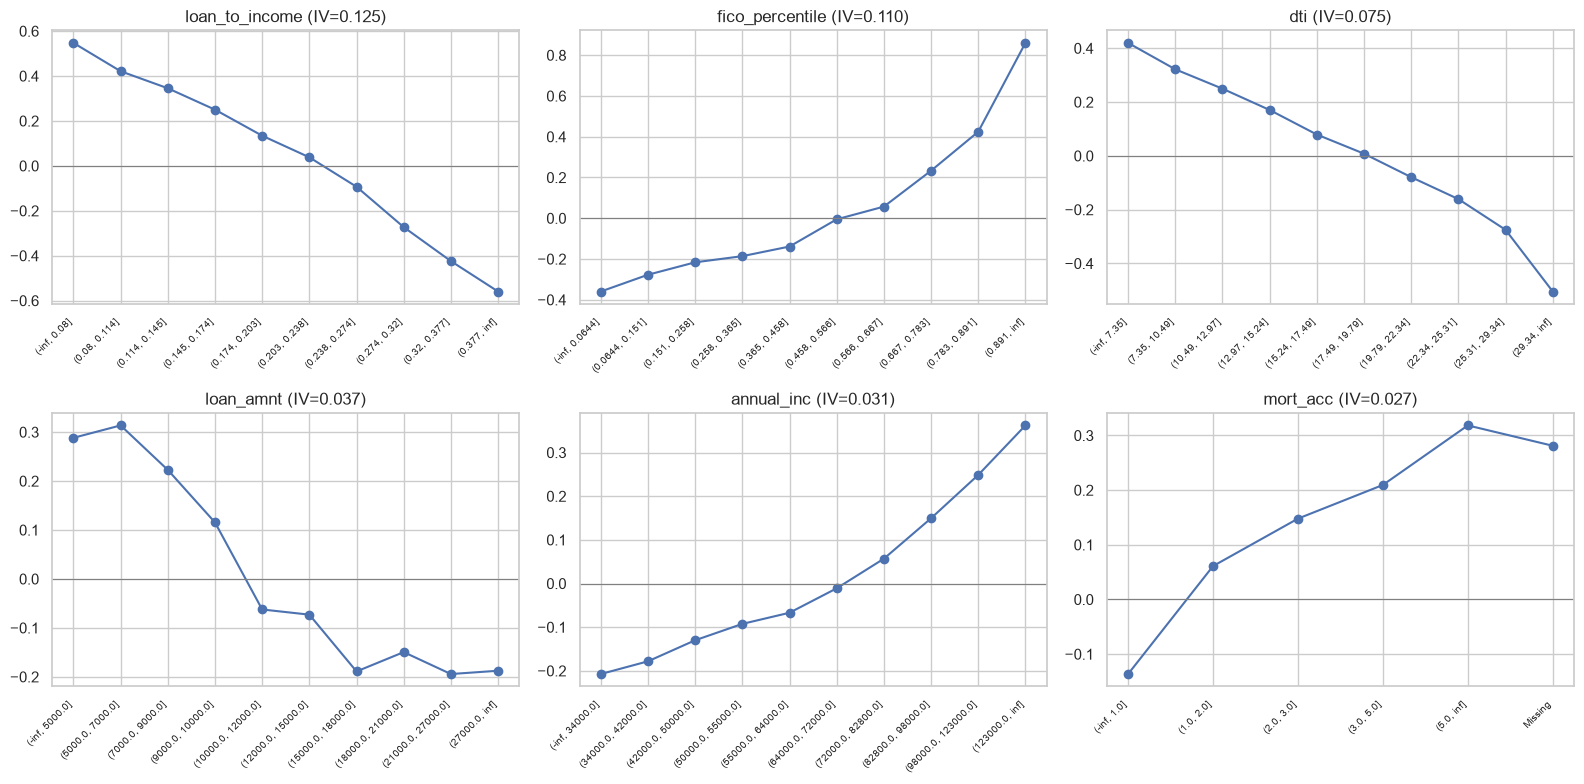

In [7]:
def sort_bins(tab):
    def sort_key(bin_label):
        if isinstance(bin_label, pd.Interval):
            return (0, bin_label.left)
        return (1, 0)
    order = sorted(tab.index, key=sort_key)
    return tab.loc[order]


top_numeric = [f for f in SELECTED_FEATURES if f in NUMERIC_FEATURES][:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feat in zip(axes.flat, top_numeric):
    tab = sort_bins(woe_tables[feat])
    ax.plot(range(len(tab)), tab["woe"], marker="o")
    ax.set_xticks(range(len(tab)))
    ax.set_xticklabels([str(i) for i in tab.index], rotation=45, ha="right", fontsize=7)
    ax.set_title(f"{feat} (IV={iv_summary[feat]:.3f})")
    ax.axhline(0, color="grey", linewidth=0.8)
plt.tight_layout()
plt.show()

## 5. Transform train & test to WOE features, fit logistic regression

In [8]:
def transform_to_woe(data, features):
    out = pd.DataFrame(index=data.index)
    for feat in features:
        woe_tab = woe_tables[feat]
        if feat in NUMERIC_FEATURES:
            binned = apply_numeric_bins(data[feat], bin_edges[feat])
        else:
            binned = apply_categorical_groups(data[feat], cat_groups[feat])
        out[feat] = binned.map(woe_tab["woe"]).fillna(0.0)
    return out

X_train = transform_to_woe(train, SELECTED_FEATURES)
X_test = transform_to_woe(test, SELECTED_FEATURES)
y_train = train["is_default"].values
y_test = test["is_default"].values

model = LogisticRegression(solver="lbfgs")
model.fit(X_train, y_train)

coef_table = pd.Series(model.coef_[0], index=SELECTED_FEATURES).sort_values()
print("Intercept:", model.intercept_[0])
coef_table

Intercept: -1.4888677993770143


fico_percentile       -1.027151
term_months           -0.970553
home_ownership        -0.722681
dti                   -0.662001
mort_acc              -0.634467
loan_to_income        -0.415316
verification_status   -0.361748
annual_inc            -0.304261
loan_amnt              0.181154
revol_util             0.399272
dtype: float64

Every WOE coefficient should be **negative**. A positive coefficient signals a badly-behaved variable (as `revol_util` has been throughout this project — likely multicollinearity, not a real effect).

In [9]:
bad_sign = coef_table[coef_table > 0]
if len(bad_sign):
    print("WARNING - unexpected positive coefficients:", bad_sign.index.tolist())
else:
    print("All coefficients have the expected negative sign.")

WARNING - unexpected positive coefficients: ['loan_amnt', 'revol_util']


## 6. Out-of-sample performance: AUC, Gini, KS

In [10]:
def ks_statistic(y_true, y_score):
    order = np.argsort(y_score)
    y_true_sorted = np.array(y_true)[order]
    cum_bad = np.cumsum(y_true_sorted) / y_true_sorted.sum()
    cum_good = np.cumsum(1 - y_true_sorted) / (1 - y_true_sorted).sum()
    return np.max(np.abs(cum_bad - cum_good))


def report_performance(y_true, proba, label):
    auc = roc_auc_score(y_true, proba)
    gini = 2 * auc - 1
    ks = ks_statistic(y_true, proba)
    print(f"{label:>12}: AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}")
    return auc, gini, ks

train_proba = model.predict_proba(X_train)[:, 1]
test_proba = model.predict_proba(X_test)[:, 1]

train_perf = report_performance(y_train, train_proba, "Train (IS)")
test_perf = report_performance(y_test, test_proba, "Test (OOS)")

print("\nFor reference, scorecard.ipynb (v1, fico_percentile only, ALL applications) scored:")
print("  Train (IS): AUC=0.6892  Gini=0.3785  KS=0.2712")
print("  Test (OOS): AUC=0.6763  Gini=0.3527  KS=0.2489")
print("(Note: that reference includes Joint App loans; this run is Individual-only, so the")
print(" comparison isn't perfectly apples-to-apples, but Joint App is only ~5% of volume.)")

  Train (IS): AUC=0.6907  Gini=0.3813  KS=0.2741
  Test (OOS): AUC=0.6794  Gini=0.3588  KS=0.2543

For reference, scorecard.ipynb (v1, fico_percentile only, ALL applications) scored:
  Train (IS): AUC=0.6892  Gini=0.3785  KS=0.2712
  Test (OOS): AUC=0.6763  Gini=0.3527  KS=0.2489
(Note: that reference includes Joint App loans; this run is Individual-only, so the
 comparison isn't perfectly apples-to-apples, but Joint App is only ~5% of volume.)


## 7. Convert to a points-based scorecard

In [11]:
BASE_SCORE = 600
BASE_ODDS = 50
PDO = 20

factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)
n_features = len(SELECTED_FEATURES)

scorecard_rows = []
for feat, coef in zip(SELECTED_FEATURES, model.coef_[0]):
    tab = woe_tables[feat]
    for bin_label, row in tab.iterrows():
        points = -(coef * row["woe"] + model.intercept_[0] / n_features) * factor + offset / n_features
        scorecard_rows.append({
            "feature": feat,
            "bin": bin_label,
            "n_train": int(row["n"]),
            "bad_rate_train": row["bad"] / row["n"],
            "woe": row["woe"],
            "points": round(points, 1),
        })

scorecard = pd.DataFrame(scorecard_rows)
scorecard.head(20)

,feature,bin,n_train,bad_rate_train,woe,points
0,term_months,36.0,618345,0.138939,0.336132,62.4
1,term_months,60.0,207860,0.318931,-0.729312,32.6
2,loan_to_income,"(-inf, 0.08]",85060,0.115530,0.547436,59.6
3,loan_to_income,"(0.08, 0.114]",80181,0.129058,0.421296,58.1
4,loan_to_income,"(0.114, 0.145]",82725,0.137830,0.345417,57.1
5,loan_to_income,"(0.145, 0.174]",82526,0.149541,0.250198,56.0
6,loan_to_income,"(0.174, 0.203]",82730,0.164898,0.134222,54.6
7,loan_to_income,"(0.203, 0.238]",82502,0.178577,0.038012,53.5
8,loan_to_income,"(0.238, 0.274]",82624,0.198623,-0.093074,51.9
9,loan_to_income,"(0.274, 0.32]",82625,0.228793,-0.272854,49.7


In [12]:
def compute_scores(X_woe):
    log_odds_bad = model.intercept_[0] + X_woe.values @ model.coef_[0]
    return offset - factor * log_odds_bad

train["score"] = compute_scores(X_train)
test["score"] = compute_scores(X_test)

print(train["score"].describe())
print(test["score"].describe())

count    826205.000000
mean        534.461783
std          20.706325
min         470.733272
25%         521.556573
50%         535.591496
75%         548.011865
max         597.197808
Name: score, dtype: float64
count    287819.000000
mean        535.305005
std          19.734795
min         473.157141
25%         523.638319
50%         535.775373
75%         547.763661
max         596.824311
Name: score, dtype: float64


In [13]:
def points_lookup(data, features):
    total = pd.Series(0.0, index=data.index)
    for feat in features:
        if feat in NUMERIC_FEATURES:
            binned = apply_numeric_bins(data[feat], bin_edges[feat])
        else:
            binned = apply_categorical_groups(data[feat], cat_groups[feat])
        points_map = scorecard[scorecard["feature"] == feat].set_index("bin")["points"]
        total = total + binned.map(points_map).fillna(0.0)
    return total

sample_idx = train.sample(2000, random_state=0).index
points_check = points_lookup(train.loc[sample_idx], SELECTED_FEATURES)
score_check = pd.Series(compute_scores(X_train.loc[sample_idx]), index=sample_idx)
max_diff = (points_check - score_check).abs().max()
print(f"Max |points-table score - compute_scores()| over sample: {max_diff:.4f}")
assert max_diff < 1.0, "Points table and compute_scores() disagree — sign/scaling bug."

Max |points-table score - compute_scores()| over sample: 0.2736


In [14]:
train_score_check = pd.qcut(train["score"], 5, duplicates="drop")
direction_check = train.groupby(train_score_check, observed=True)["is_default"].mean()
print(direction_check)
assert direction_check.iloc[0] > direction_check.iloc[-1], "Score is inverted."
print("Score direction confirmed: higher score -> lower default rate.")

score
(470.732, 517.217]    0.358410
(517.217, 530.801]    0.215733
(530.801, 540.242]    0.158762
(540.242, 551.223]    0.119135
(551.223, 597.198]    0.069069
Name: is_default, dtype: float64
Score direction confirmed: higher score -> lower default rate.


## 8. Calibration on the out-of-time test set

In [15]:
test["score_band"] = pd.qcut(test["score"], 10, duplicates="drop")
calibration = test.groupby("score_band", observed=True).agg(
    n=("is_default", "size"),
    actual_default_rate=("is_default", "mean"),
    avg_score=("score", "mean"),
).sort_values("avg_score", ascending=False)
calibration

,n,actual_default_rate,avg_score
score_band,,,
"(560.462, 596.824]",28782,0.067125,569.809657
"(551.046, 560.462]",28782,0.118581,555.305885
"(544.993, 551.046]",28782,0.149781,547.859220
"(540.144, 544.993]",28782,0.175700,542.499223
"(535.775, 540.144]",28781,0.202356,537.937179
"(531.423, 535.775]",28782,0.231047,533.612942
"(526.563, 531.423]",28781,0.261735,529.065799
"(520.018, 526.563]",28783,0.294827,523.519307
"(508.803, 520.018]",28782,0.347092,515.008140


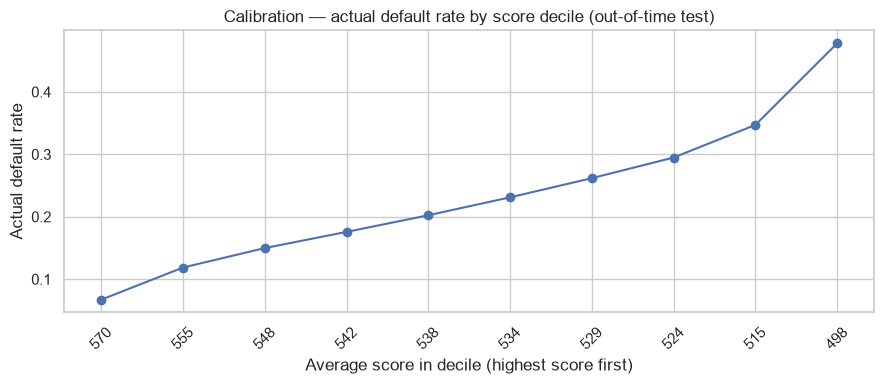

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(len(calibration)), calibration["actual_default_rate"], marker="o")
ax.set_xticks(range(len(calibration)))
ax.set_xticklabels([f"{v:.0f}" for v in calibration["avg_score"]], rotation=45)
ax.set_xlabel("Average score in decile (highest score first)")
ax.set_ylabel("Actual default rate")
ax.set_title("Calibration — actual default rate by score decile (out-of-time test)")
plt.tight_layout()
plt.show()

## 9. Population Stability Index (PSI): train vs. out-of-time test

In [17]:
def psi(expected, actual, bins=10):
    edges = np.quantile(expected, np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    edges = np.unique(edges)
    e_counts = np.histogram(expected, bins=edges)[0] / len(expected)
    a_counts = np.histogram(actual, bins=edges)[0] / len(actual)
    e_counts = np.where(e_counts == 0, 1e-6, e_counts)
    a_counts = np.where(a_counts == 0, 1e-6, a_counts)
    return np.sum((a_counts - e_counts) * np.log(a_counts / e_counts))

psi_value = psi(train["score"].values, test["score"].values)
print(f"PSI (train -> 2016 test): {psi_value:.4f}")

PSI (train -> 2016 test): 0.0090


## 10. Summary

- Same out-of-time design and leakage-avoidance rules as `scorecard.ipynb`: train
  on loans issued 2007–2015, test on 2016; no `grade`/`sub_grade`/`int_rate`/
  `installment`; FICO handled as a rolling percentile.
- **Filtered to Individual applications only**, dropping 120,710 Joint App loans
  (~5.3% of the full dataset) — see the intro for why. Individual-only counts:
  826,205 train loans (18.42% default) and 287,819 test loans (23.26% default),
  each about 400-5,300 fewer than the all-applications numbers.
- **Feature set:** v1's features plus `loan_to_income`, which still clears the IV
  bar cleanly on this population (IV = 0.1253, essentially identical to its 0.125
  on the full mixed population) and remains the second-strongest predictor behind
  `term_months`.
- **Result: filtering out Joint App loans made almost no difference, and if
  anything nudged performance up slightly.** Test Gini: 0.3527 (v1, all
  applications) -> 0.3578 (v1 features + `loan_to_income`, all applications) ->
  **0.3588** (same features, Individual-only). Test AUC 0.6794 vs. 0.6763 (v1),
  test KS 0.2543 vs. 0.2489 (v1). The Joint App population is small enough
  (~5.3%) that excluding it doesn't materially change what the model learns —
  this confirms the segmentation is *conceptually* the right call (Joint App
  loans have structurally different income/DTI fields) without costing anything
  in raw performance.
- `loan_amnt` and `revol_util` both remain flipped positive, unchanged from prior
  versions — `loan_amnt` from sharing a component with `loan_to_income`,
  `revol_util` for reasons that have been unstable throughout this project. Both
  are still worth a dedicated refinement pass (e.g. dropping `loan_amnt` given
  `loan_to_income` carries far more IV on its own).
- Both sanity checks passed; PSI (train -> 2016 test) = 0.0090, still stable.